In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/Extras/LPD")
from lpd_resnet18_match import LPDResNet18Match

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
class TauScheduler:
    """Zero-order-hold Gumbel-softmax temperature annealing, plain-PyTorch
    equivalent of their MultiStep(rate='zero') callback. Milestones/values
    are a reasonable starting guess (not their exact published numbers,
    which we don't have) -- treat as a tunable hyperparameter."""
    def __init__(self, milestones=(50, 100, 150), temperatures=(0.5, 0.2, 0.1)):
        assert len(milestones) == len(temperatures)
        self.milestones = milestones
        self.temperatures = temperatures
        self.epoch = 0

    def step(self, model):
        self.epoch += 1
        idx = -1
        for i, m in enumerate(self.milestones):
            if self.epoch >= m:
                idx = i
        if idx < 0:
            return  # before first milestone: tau stays at its initial value (1.0)
        new_tau = self.temperatures[idx]
        for n, p in model.named_buffers():
            if "gumbel_tau" in n:
                p.fill_(new_tau)

In [4]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [5]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [6]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [8]:
seed_lst = [10, 42, 100, 123, 666]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    # --- CHANGED: LPD-ResNet18 instead of models.resnet18 ---
    # Dropout head is already built into LPDResNet18 (dropout_p=0.4 default),
    # so no separate model.fc = nn.Sequential(...) override needed here.
    model = LPDResNet18Match(num_classes = len(train_ds.class_to_idx), conv1_stride = False, swap_conv_pool = True)
 
    # Define the loss function and optimizer
    criterion = nn.NLLLoss()
 
    # --- CHANGED: split params so LPD's internal phase-selection logits
    # (component_selection submodules) get weight_decay=0, everything
    # else (backbone convs/BN/fc) keeps your usual 2e-4. See paper
    # Appendix A4.4.1 for why: weight decay on the selection logits
    # pushes them toward equal magnitude, which destabilizes the hard
    # phase selection the shift-invariance guarantee depends on.
    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
 
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
 
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
    tau_scheduler = TauScheduler()
 
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            # --- CHANGED: conv1 now lives under model.core.conv1,
            # since LPDResNet18 wraps a torchvision ResNet as self.core
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        tau_scheduler.step(model)
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_nllloss_tau.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000035
train Loss: 2.3724622490 Acc: 0.1898263027
val Loss: 3.0289472720 Acc: 0.1464019851
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 2.0595153165 Acc: 0.2084367246
val Loss: 2.4963786478 Acc: 0.1302729529
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.9431220473 Acc: 0.2766749380
val Loss: 2.3020441207 Acc: 0.1749379653
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.8040043261 Acc: 0.3387096774
val Loss: 2.2473037125 Acc: 0.1712158809
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.5697821947 Acc: 0.4305210918
val Loss: 4.5412669640 Acc: 0.1885856079
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 1.3109198619 Acc: 0.4875930521
val Loss: 2.6361848989 Acc: 0.1439205955
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 1.2546351175 Acc: 0.4975186104
val Loss: 4.3047707211 Acc: 0.2183622829
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 1.6866116524 Acc: 0.3660049628
val Loss: 1.8702236586 Acc: 0.3486352357
Epoch 7 LR: 0.0002988184
Epoch 8
train

In [9]:
frozen = [n for n, p in model.named_parameters() if not p.requires_grad]
print(frozen)  # should print an empty list []

[]


In [10]:
[n for n, p in model.named_parameters() if "get_logits" in n]

['core.maxpool.0.component_selection.get_logits.conv1.weight',
 'core.maxpool.0.component_selection.get_logits.conv1.bias',
 'core.maxpool.0.component_selection.get_logits.conv2.weight',
 'core.maxpool.0.component_selection.get_logits.conv2.bias',
 'core.maxpool.3.component_selection.get_logits.conv1.weight',
 'core.maxpool.3.component_selection.get_logits.conv1.bias',
 'core.maxpool.3.component_selection.get_logits.conv2.weight',
 'core.maxpool.3.component_selection.get_logits.conv2.bias',
 'core.layer2.0.conv2.1.component_selection.get_logits.conv1.weight',
 'core.layer2.0.conv2.1.component_selection.get_logits.conv1.bias',
 'core.layer2.0.conv2.1.component_selection.get_logits.conv2.weight',
 'core.layer2.0.conv2.1.component_selection.get_logits.conv2.bias',
 'core.layer3.0.conv2.1.component_selection.get_logits.conv1.weight',
 'core.layer3.0.conv2.1.component_selection.get_logits.conv1.bias',
 'core.layer3.0.conv2.1.component_selection.get_logits.conv2.weight',
 'core.layer3.0.conv

In [11]:
pool_param_count = sum(p.numel() for n, p in model.named_parameters() if "component_selection" in n)
total_param_count = sum(p.numel() for p in model.parameters())
print(f"LPD component_selection params: {pool_param_count} ({100*pool_param_count/total_param_count:.2f}% of total)")

LPD component_selection params: 6342656 (36.19% of total)


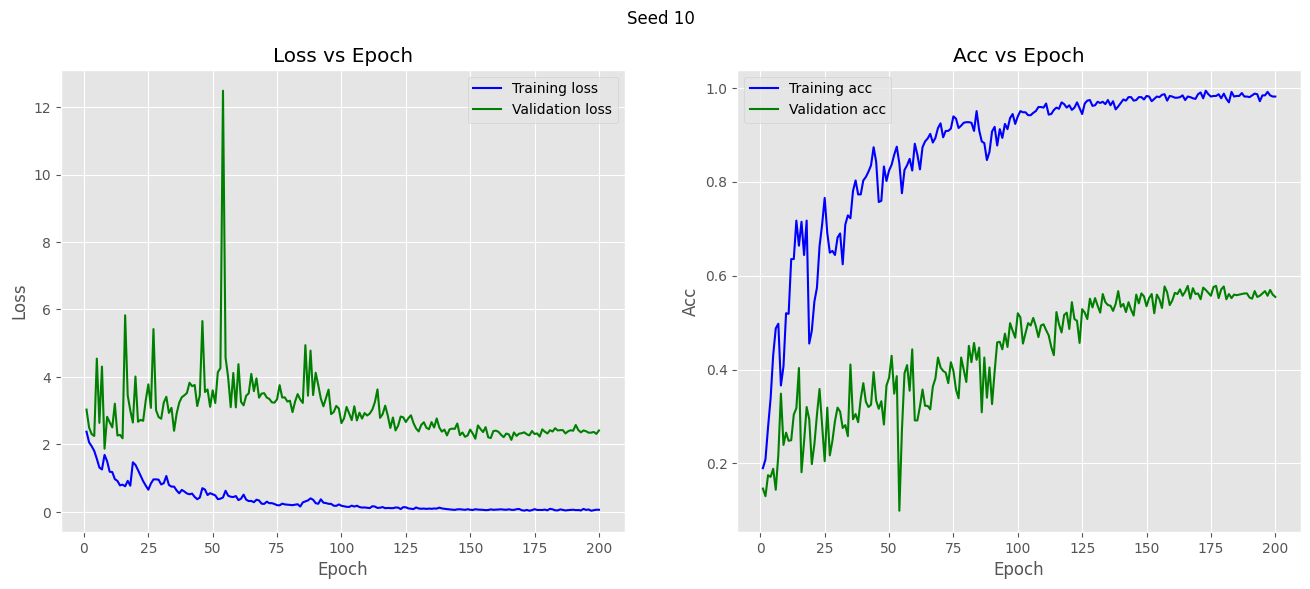

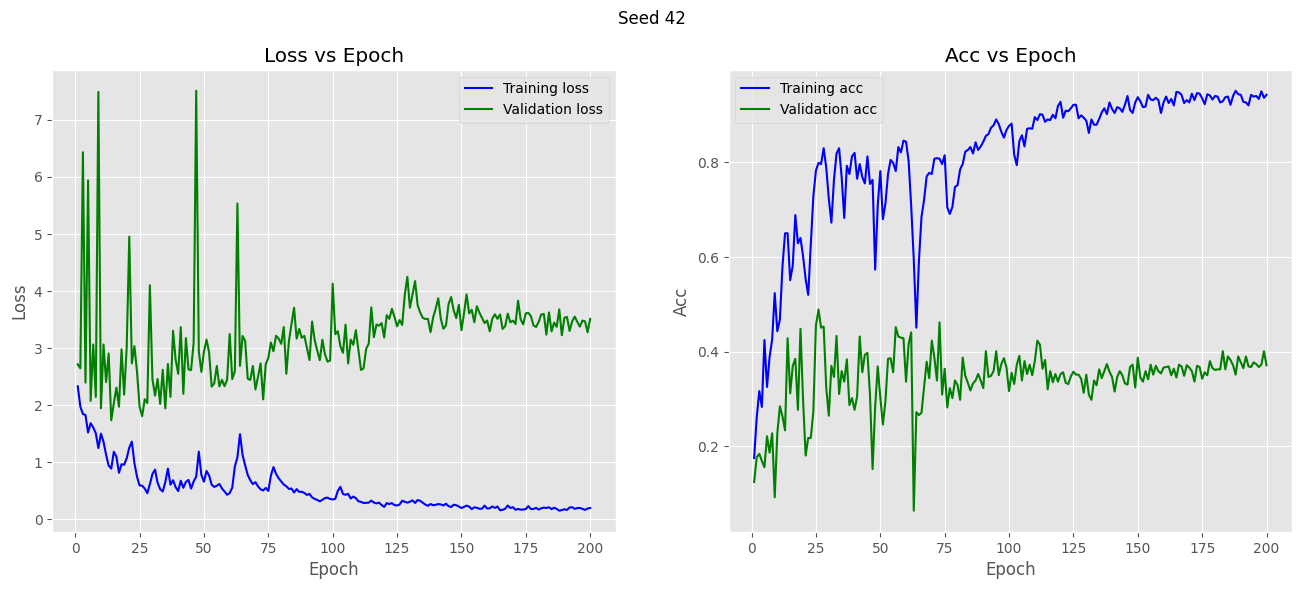

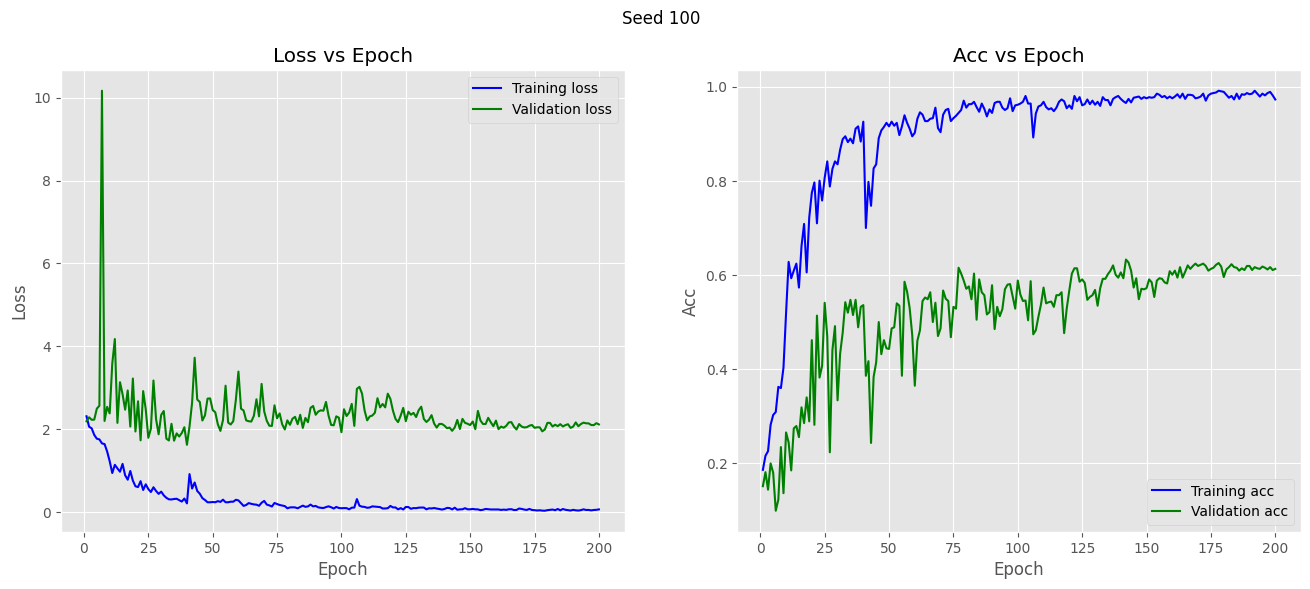

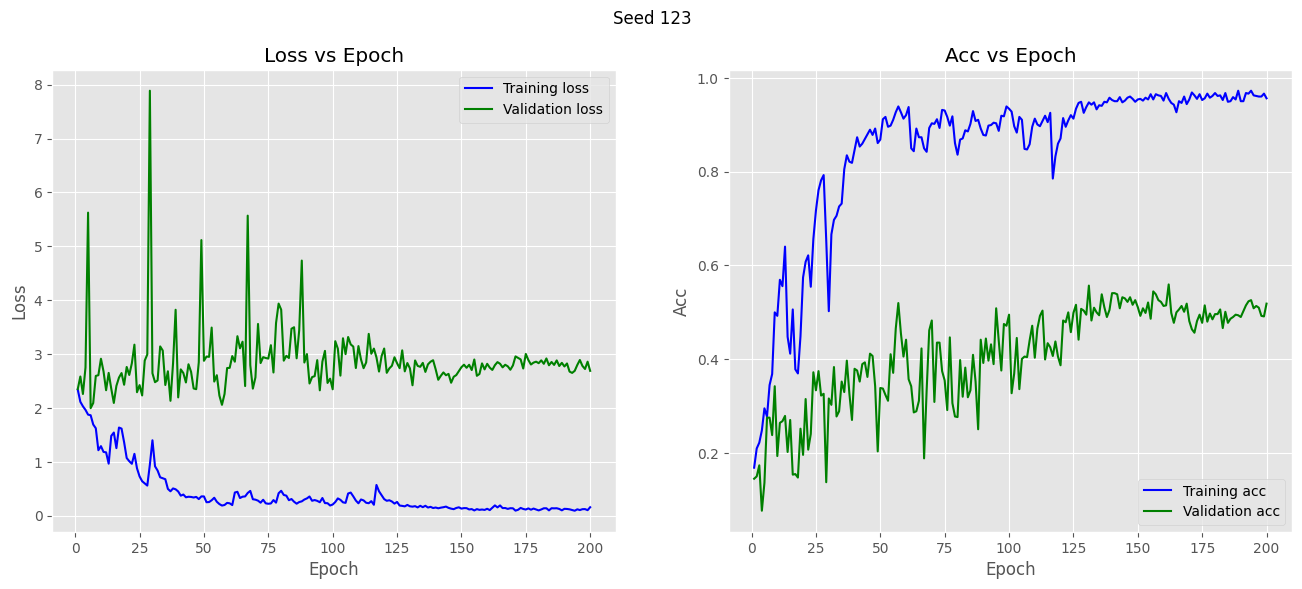

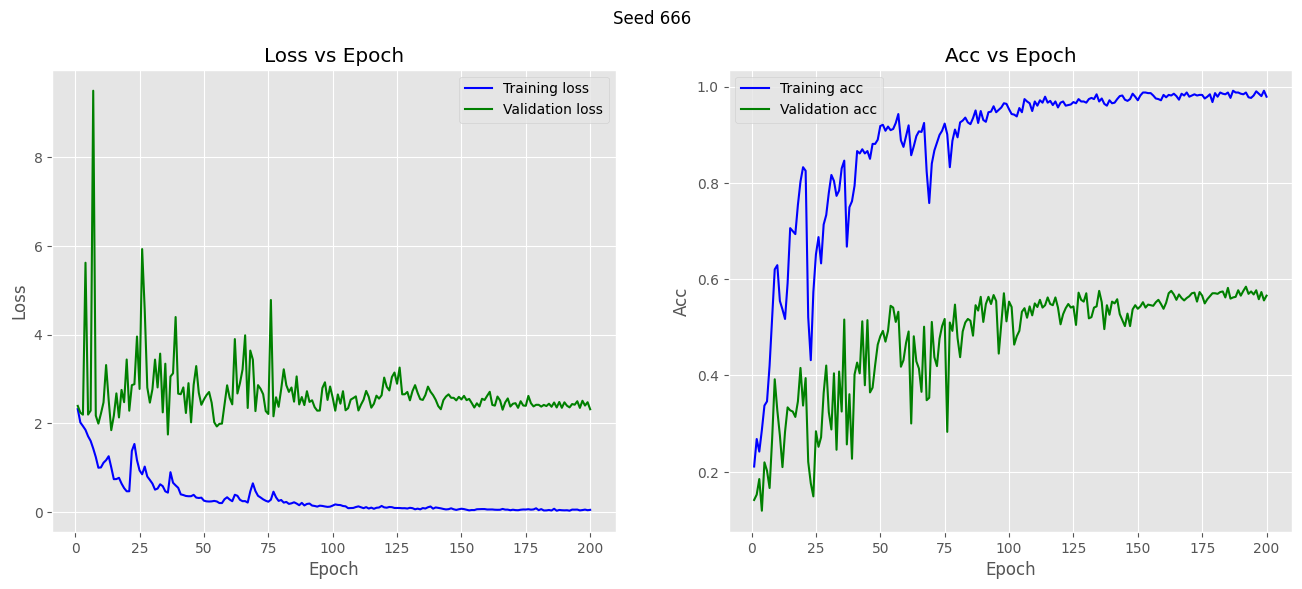

In [12]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = LPDResNet18Match(num_classes = len(train_ds.class_to_idx), conv1_stride = False, swap_conv_pool = True) # dont load ImageNet Weights
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_nllloss.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.6382
Evaluating Run 1: Seed 42
Test Accuracy: 0.4360
Evaluating Run 2: Seed 100
Test Accuracy: 0.7124
Evaluating Run 3: Seed 123
Test Accuracy: 0.5900
Evaluating Run 4: Seed 666
Test Accuracy: 0.6327


In [14]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: Seed {seed}")
        new_model = LPDResNet18Match(num_classes = len(train_ds.class_to_idx), conv1_stride = False, swap_conv_pool = True) # dont load ImageNet Weights
        
        # Load your trained weights
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_nllloss.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
    
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {test_acc:.4f}")
        test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.6382
Evaluating Run 1: Seed 42
Test Accuracy: 0.4360
Evaluating Run 2: Seed 100
Test Accuracy: 0.7124
Evaluating Run 3: Seed 123
Test Accuracy: 0.5900
Evaluating Run 4: Seed 666
Test Accuracy: 0.6327
Evaluating Run 0: Seed 10
Test Accuracy: 0.6382
Evaluating Run 1: Seed 42
Test Accuracy: 0.4360
Evaluating Run 2: Seed 100
Test Accuracy: 0.7124
Evaluating Run 3: Seed 123
Test Accuracy: 0.5900
Evaluating Run 4: Seed 666
Test Accuracy: 0.6327
Evaluating Run 0: Seed 10
Test Accuracy: 0.6382
Evaluating Run 1: Seed 42
Test Accuracy: 0.4360
Evaluating Run 2: Seed 100
Test Accuracy: 0.7143
Evaluating Run 3: Seed 123
Test Accuracy: 0.5900
Evaluating Run 4: Seed 666
Test Accuracy: 0.6327
Evaluating Run 0: Seed 10
Test Accuracy: 0.6382
Evaluating Run 1: Seed 42
Test Accuracy: 0.4360
Evaluating Run 2: Seed 100
Test Accuracy: 0.7124
Evaluating Run 3: Seed 123
Test Accuracy: 0.5900
Evaluating Run 4: Seed 666
Test Accuracy: 0.6327
